In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.losses import CategoricalCrossentropy
from sklearn.metrics import classification_report, f1_score, accuracy_score

era5 = xr.open_dataset(r"D:\\Documents\\thesis\\processed_data\\era5-land-all-variables\\era5land_ebro_daily_mean3.nc")
df = era5.to_dataframe()

df['day_of_year'] = df.index.dayofyear

# Ensure your time column is datetime and extract the month
df['time'] = pd.to_datetime(df.index)
df['month'] = df['time'].dt.month
# This helps the model understand that Dec and Jan are neighbors
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Calculate Mean and Std Dev per month (and per pixel/station if applicable)
stats = df.groupby('month')['swvl1'].agg(['mean', 'std']).reset_index()

# Merge stats back to original dataframe
df = df.merge(stats, on='month')

# Calculate Z-score
df['z_score'] = (df['swvl1'] - df['mean']) / df['std']

# Create Buckets
bins = [-float('inf'), -0.5, 0.5, float('inf')]
labels = ['Severely Dry', 'Moderately Dry', 'Normal', 'Moderately Wet', 'Severely Wet']
labels = [0, 1, 2]
df['category'] = pd.cut(df['z_score'], bins=bins, labels=labels).astype(int)
df["target_next_month"] = df["category"].shift(-30)
df['tp_30d_sum'] = df['tp'].rolling(window=30, center=False).sum()
df = df.dropna()

In [ ]:
def set_seeds(seed=2):
    # Set basic Python/Numpy seeds
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    
    # Set TF seed
    tf.random.set_seed(seed)
    
    # Force determinism
    # This replaces the need for the environment variable in newer TF versions
    tf.config.experimental.enable_op_determinism() 
    
    # If using GPU, some ops still might be non-deterministic
    # This environment variable is a good backup
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

set_seeds(2)

def prepare_data_for_lead_time(df, lead_time, seq_length=30):
    """
    Dynamically shifts the target variable to the requested lead time
    and prepares the 3D sequences for the LSTM.
    Also returns persistence-baseline labels.
    """
    cols_to_drop = ['target_next_month', 'time']
    features_df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    features_df = features_df[top_features]

    y_raw = df['category'].values
    X_raw = features_df.values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)

    X_seq, y_seq, y_persist = [], [], []

    for i in range(len(X_scaled) - seq_length - lead_time + 1):
        X_seq.append(X_scaled[i:i + seq_length])

        target_idx = i + seq_length + lead_time - 1
        y_seq.append(y_raw[target_idx])

        # Persistence baseline: predict the last observed class in the input window
        y_persist.append(y_raw[i + seq_length - 1])

    X_seq = np.array(X_seq)
    y_seq = np.array(y_seq).astype(int)
    y_persist = np.array(y_persist).astype(int)

    y_encoded = to_categorical(y_seq, num_classes=3)

    split_idx = int(len(X_seq) * 0.8)

    X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
    y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

    y_persist_train = y_persist[:split_idx]
    y_persist_test = y_persist[split_idx:]
    y_true_test = y_seq[split_idx:]

    y_train_flat = np.argmax(y_train, axis=1)
    weights = compute_class_weight(
        'balanced',
        classes=np.unique(y_train_flat),
        y=y_train_flat
    )
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    return X_train, X_test, y_train, y_test, class_weights_dict, y_persist_test, y_true_test

def train_evaluate_lstm(X_train, X_test, y_train, y_test, weights_dict, lead_time):
    model = Sequential()

    model.add(
        LSTM(
            units=16,
            input_shape=(X_train.shape[1], X_train.shape[2]),
            kernel_regularizer=regularizers.l2(0.01),
            recurrent_regularizer=regularizers.l2(0.01),
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )

    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=64,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        class_weight=weights_dict,
        verbose=0
    )

    # Get probability predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    
    # Convert probabilities and one-hot labels to integer class indices
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Calculate Macro F1
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Generate per-class Recall and F1 using classification_report
    # output_dict=True allows you to access metrics programmatically
    report = classification_report(y_true, y_pred, output_dict=True)
    
    print(f"\n--- Results for Lead Time: {lead_time} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1 Score: {macro_f1:.4f}")
    
    # Print per-class metrics clearly
    for class_id in ['0', '1', '2']:
        if class_id in report:
            f1 = report[class_id]['f1-score']
            recall = report[class_id]['recall']
            print(f"Class {class_id} -> Recall: {recall:.4f}, F1: {f1:.4f}")

    # Get probability predictions
    y_pred_probs = model.predict(X_test, verbose=0)

    return accuracy, y_pred_probs, model

In [ ]:
# 1-Day model
X_train_1, X_test_1, y_train_1, y_test_1, w1, _, _ = prepare_data_for_lead_time(df, 1)
acc_1, probs_1, model_1 = train_evaluate_lstm(X_train_1, X_test_1, y_train_1, y_test_1, w1, 1)
print(acc_1)

c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Results for Lead Time: 1 ---
Macro F1 Score: 0.8558
Class 0 -> Recall: 0.8941, F1: 0.8946
Class 1 -> Recall: 0.7976, F1: 0.8011
Class 2 -> Recall: 0.8764, F1: 0.8716
0.854279100894928


In [ ]:
# 7-Day model
X_train_7, X_test_7, y_train_7, y_test_7, w7, _, _ = prepare_data_for_lead_time(df, 7)
acc_7, probs_7, model_7 = train_evaluate_lstm(X_train_7, X_test_7, y_train_7, y_test_7, w7, 7)
print(acc_7)

c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


0.5190898776054382


In [ ]:
# 14-Day model
X_train_14, X_test_14, y_train_14, y_test_14, w14, _, _ = prepare_data_for_lead_time(df, 14)
acc_14, probs_14, model_14 = train_evaluate_lstm(X_train_14, X_test_14, y_train_14, y_test_14, w14, 14)
print(acc_14)

c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


0.4344135820865631


In [7]:
# 30-Day model
X_train_30, X_test_30, y_train_30, y_test_30, w30, _, _ = prepare_data_for_lead_time(df, 30)
acc_30, probs_30, model_30 = train_evaluate_lstm(X_train_30, X_test_30, y_train_30, y_test_30, w30, 30)
print(acc_30)

c:\Users\albat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


0.3736476004123688


Permutation feature importance

In [ ]:
def permutation_importance_lstm_final(model, X_test, y_test, feature_names):
    print("--- Starting Corrected Permutation Importance ---")
    
    # Convert y_test to class indices if it is One-Hot Encoded
    if len(y_test.shape) > 1 and y_test.shape[1] > 1:
        y_test_indices = np.argmax(y_test, axis=1)
    else:
        y_test_indices = y_test

    # Get baseline accuracy
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    baseline_acc = accuracy_score(y_test_indices, y_pred)
    print(f"Baseline Accuracy: {baseline_acc:.4f}")
    
    importances = []
    
    # Loop through each feature
    for i, feature in enumerate(feature_names):
        X_permuted = X_test.copy()
        
        # Shuffle this feature across all samples and timesteps
        save_col = X_permuted[:, :, i].copy()
        flat_col = save_col.flatten()
        np.random.shuffle(flat_col)
        X_permuted[:, :, i] = flat_col.reshape(save_col.shape)
        
        # Predict with permuted data
        y_pred_perm_probs = model.predict(X_permuted, verbose=0)
        y_pred_perm = np.argmax(y_pred_perm_probs, axis=1)
        perm_acc = accuracy_score(y_test_indices, y_pred_perm)
        
        # Drop in accuracy is the importance
        drop = baseline_acc - perm_acc
        importances.append(drop)
        print(f"Feature '{feature}' importance: {drop:.4f}")

    # Plotting
    importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='#3498db')
    plt.axvline(0, color='black', lw=1)
    plt.xlabel("Decrease in Accuracy (Importance)")
    plt.title("Physical Variable Importance (30-Day Lead)")
    plt.tight_layout()
    plt.show()

    return importance_df

# Ensure final_features is exactly what the model was trained on (10 items)
final_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m', 'swvl3', 'e', 'stl1', 'tp_30d_sum']

--- Starting Corrected Permutation Importance ---
Baseline Accuracy: 0.8119
Feature 'swvl1' importance: 0.3655
Feature 'sro' importance: 0.0316
Feature 'std' importance: 0.0162
Feature 'slhf' importance: 0.0231
Feature 'month_cos' importance: 0.0459
Feature 'd2m' importance: 0.0725
Feature 'swvl3' importance: 0.0069
Feature 'e' importance: 0.0231
Feature 'stl1' importance: 0.0274
Feature 'tp_30d_sum' importance: 0.0405


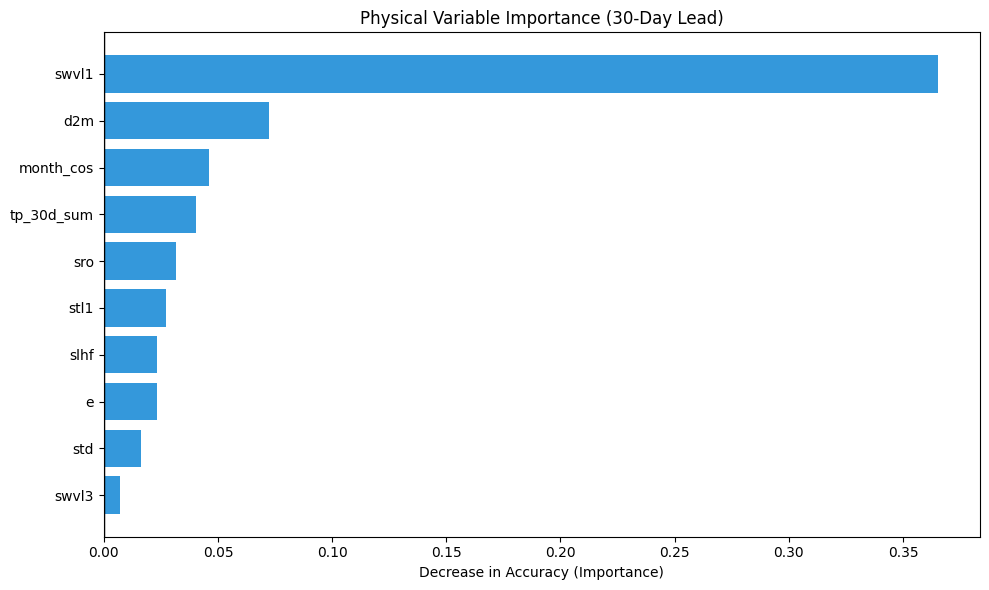

In [9]:
results_1 = permutation_importance_lstm_final(model_1, X_test_1, y_test_1, final_features)

--- Starting Corrected Permutation Importance ---
Baseline Accuracy: 0.5318
Feature 'swvl1' importance: 0.0910
Feature 'sro' importance: 0.0027
Feature 'std' importance: -0.0019
Feature 'slhf' importance: 0.0027
Feature 'month_cos' importance: 0.0077
Feature 'd2m' importance: 0.0039
Feature 'swvl3' importance: -0.0019
Feature 'e' importance: 0.0042
Feature 'stl1' importance: 0.0000
Feature 'tp_30d_sum' importance: 0.0278


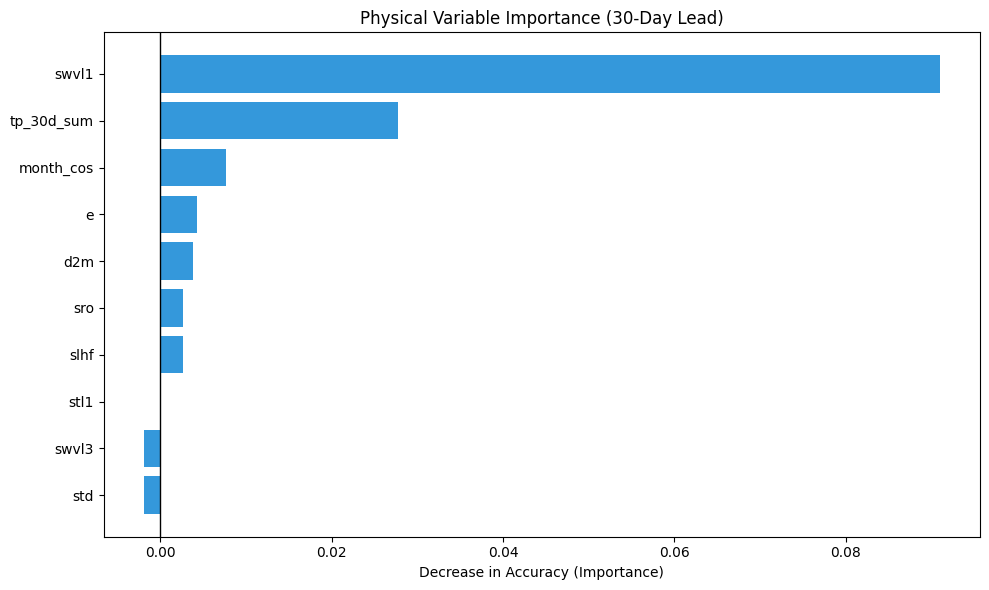

In [11]:
results_7 = permutation_importance_lstm_final(model_7, X_test_7, y_test_7, final_features)

--- Starting Corrected Permutation Importance ---
Baseline Accuracy: 0.4614
Feature 'swvl1' importance: 0.0610
Feature 'sro' importance: 0.0054
Feature 'std' importance: 0.0089
Feature 'slhf' importance: -0.0046
Feature 'month_cos' importance: 0.0008
Feature 'd2m' importance: 0.0042
Feature 'swvl3' importance: 0.0116
Feature 'e' importance: 0.0035
Feature 'stl1' importance: 0.0046
Feature 'tp_30d_sum' importance: 0.0382


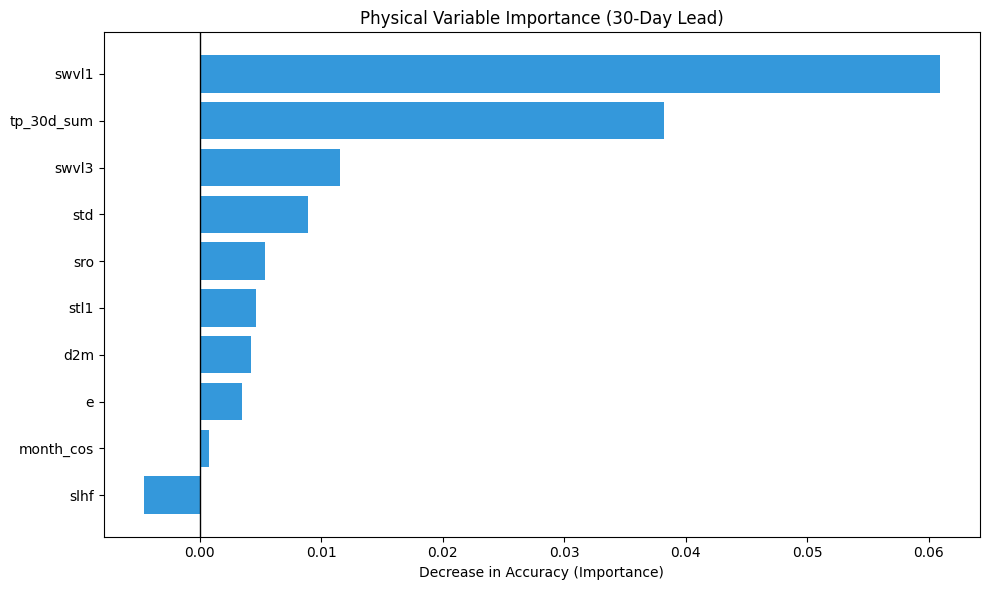

In [12]:
results_14 = permutation_importance_lstm_final(model_14, X_test_14, y_test_14, final_features)

In [ ]:
def class_specific_importance(model, X_test, y_test, feature_names):
    y_test_indices = np.argmax(y_test, axis=1)
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    class_names = ['Dry', 'Normal', 'Wet']
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for class_idx, class_label in enumerate(class_names):
        # Baseline F1-score for this specific class
        baseline_f1 = f1_score(y_test_indices, y_pred, labels=[class_idx], average='macro')
        
        importances = []
        for i in range(len(feature_names)):
            X_permuted = X_test.copy()
            flat_col = X_permuted[:, :, i].flatten()
            np.random.shuffle(flat_col)
            X_permuted[:, :, i] = flat_col.reshape(X_test.shape[0], X_test.shape[1])
            
            y_pred_perm = np.argmax(model.predict(X_permuted, verbose=0), axis=1)
            perm_f1 = f1_score(y_test_indices, y_pred_perm, labels=[class_idx], average='macro')
            
            importances.append(baseline_f1 - perm_f1)
        
        # Plotting for this class
        df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance')
        axes[class_idx].barh(df['Feature'], df['Importance'], color=['#e74c3c' if class_idx==0 else '#f1c40f' if class_idx==1 else '#3498db'])
        axes[class_idx].set_title(f"Importance for: {class_label}")
        axes[class_idx].axvline(0, color='black', lw=0.8)

    plt.tight_layout()
    plt.show()
final_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m', 'swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']

In this next part, I iteratively removed the less important feature and I performed this analysis for 1-day, 14-day and 30-day lead times

In [ ]:
# # 1 day
# top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m','swvl3', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'month_cos', 'd2m', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'month_cos', 'd2m', 'category']
# top_features = ['swvl1', 'month_cos', 'd2m', 'category']
# top_features = ['swvl1', 'd2m', 'category']
# top_features = ['swvl1', 'category']
# top_features = ['category']

In [ ]:
# 14 day
# top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
# top_features = ['swvl1', 'sro', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum']
# top_features = ['swvl1', 'sro', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum']
# top_features = ['swvl1', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum']
# top_features = ['swvl1', 'd2m','swvl3', 'stl1', 'tp_30d_sum']
# top_features = ['swvl1', 'd2m','swvl3', 'tp_30d_sum']
# top_features = ['swvl1', 'd2m', 'tp_30d_sum']
# top_features = ['swvl1', 'tp_30d_sum']
# top_features = ['swvl1']

In [114]:
# 30 day
top_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m','swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m','swvl3', 'stl1', 'tp_30d_sum', 'category']
top_features = ['swvl1', 'sro', 'slhf', 'month_cos', 'd2m', 'stl1', 'tp_30d_sum', 'category']
top_features = ['swvl1', 'slhf', 'month_cos', 'd2m', 'stl1', 'tp_30d_sum', 'category']
top_features = ['slhf', 'month_cos', 'd2m', 'stl1', 'tp_30d_sum', 'category']
top_features = ['slhf', 'd2m', 'stl1', 'tp_30d_sum', 'category']
top_features = ['slhf', 'd2m', 'tp_30d_sum', 'category']
top_features = ['slhf', 'tp_30d_sum', 'category']
top_features = ['slhf', 'tp_30d_sum']
top_features = ['tp_30d_sum']

Rerun the model with one less feature each time

In [ ]:
# # 30-Day model
# X_train_30, X_test_30, y_train_30, y_test_30, w30, _, _ = prepare_data_for_lead_time(df, 30)
# acc_30, probs_30, model_30 = train_evaluate_lstm(X_train_30, X_test_30, y_train_30, y_test_30, w30, 30)

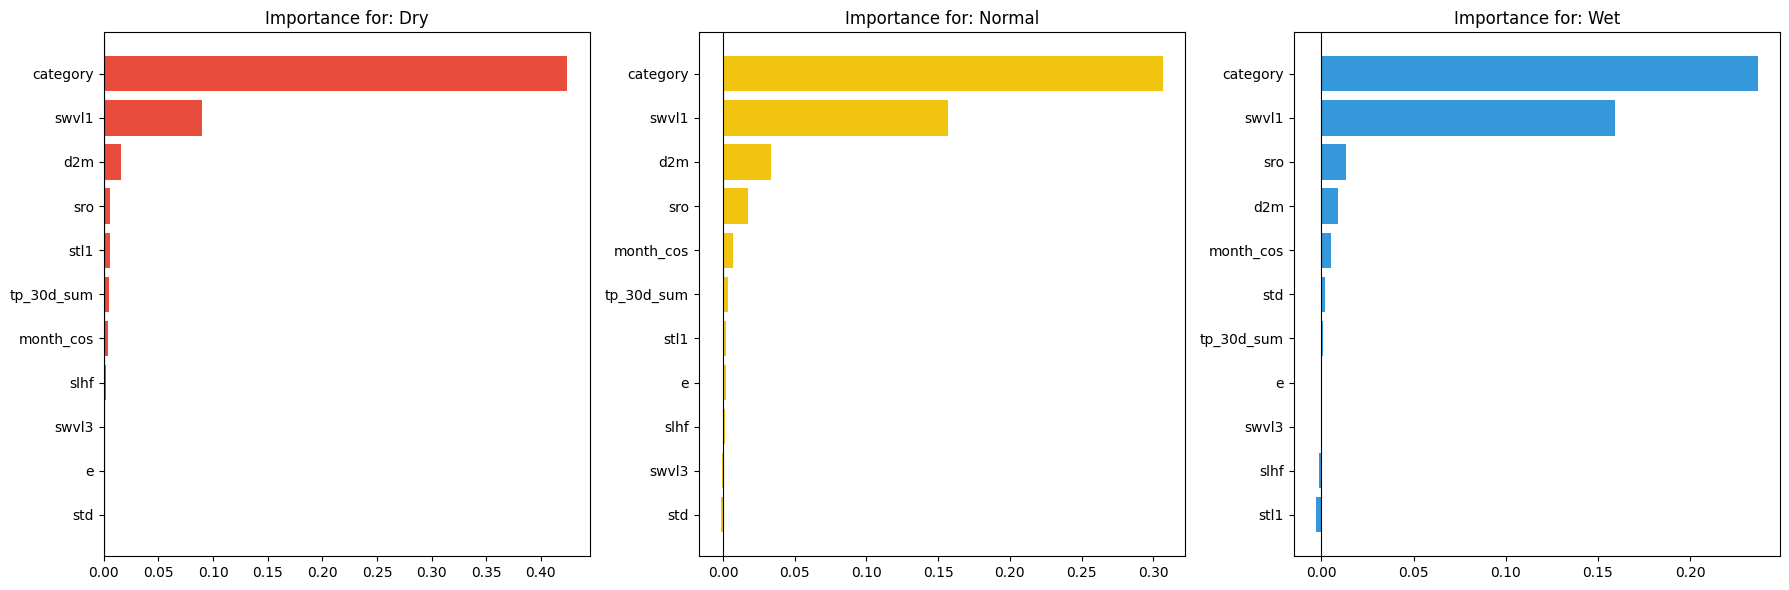

In [ ]:
final_features = ['swvl1', 'sro', 'std', 'slhf', 'month_cos', 'd2m', 'swvl3', 'e', 'stl1', 'tp_30d_sum', 'category']
class_specific_importance(model_1, X_test_1, y_test_1, final_features)

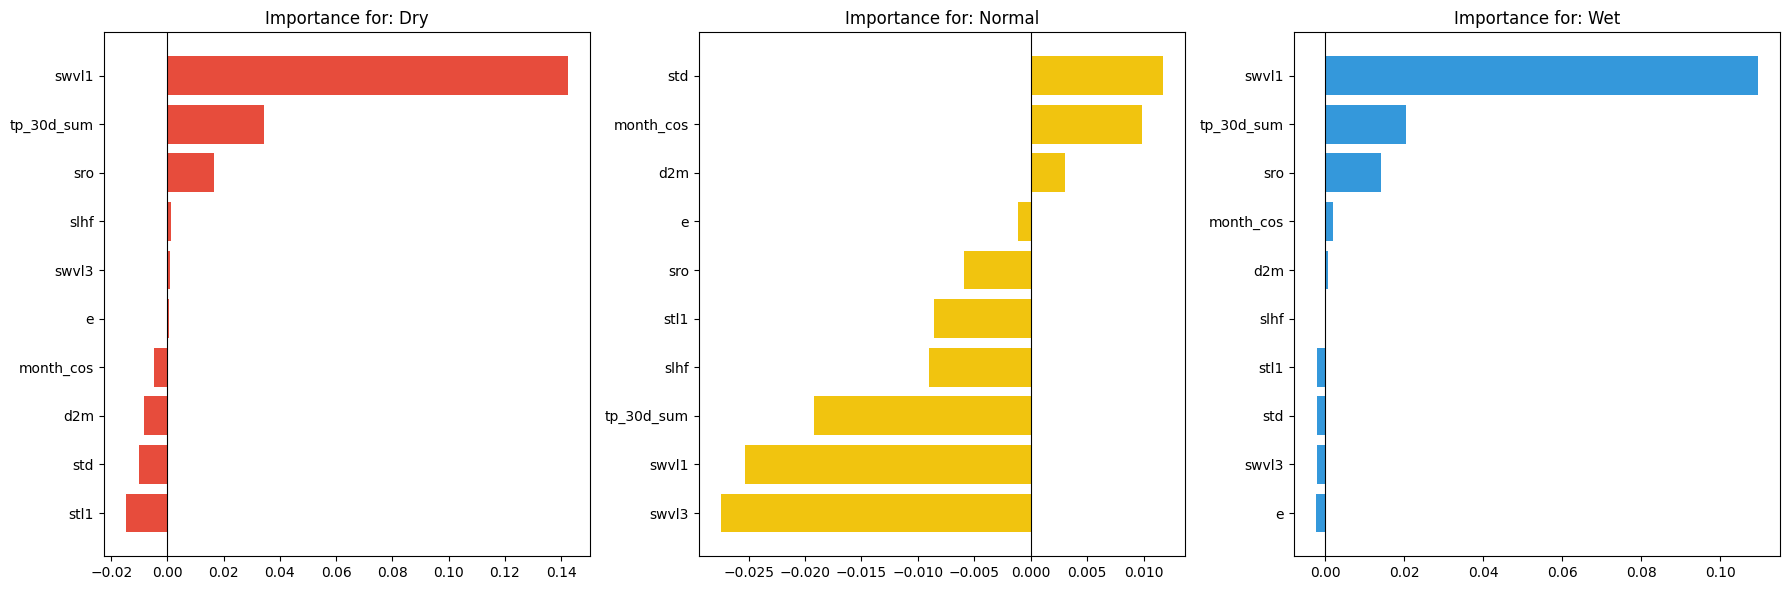

In [6]:
class_specific_importance(model_7, X_test_7, y_test_7, final_features)

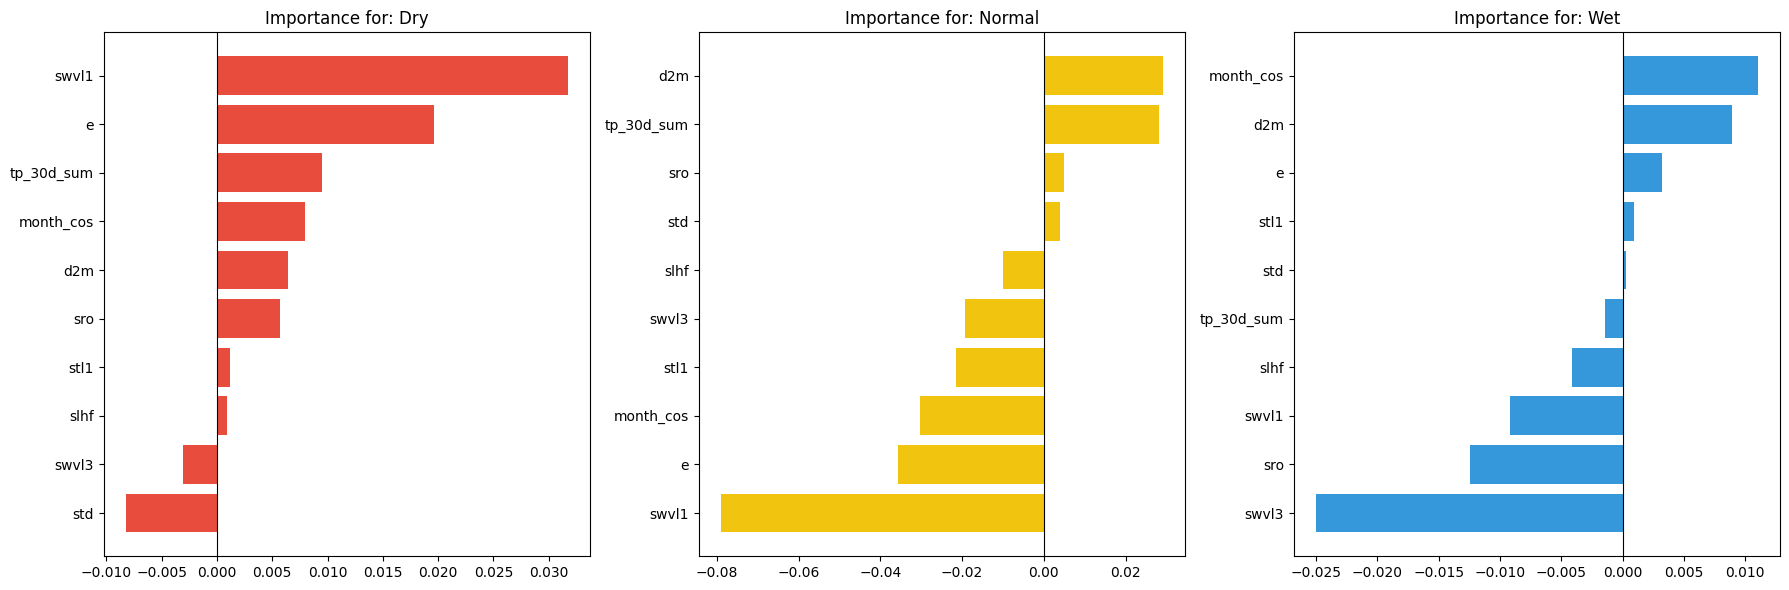

In [8]:
class_specific_importance(model_30, X_test_30, y_test_30, final_features)